# Data Exploartion

#### 1. Load data

In [1]:
import pandas as pd

df = pd.read_csv('./soccer_news.csv')
df.head()

,title,text,url,publisher,dt
0,"""독일어 수업, 팀 내부 사이도 좋아""...'바이에른 뮌헨서 살아남기' 잭슨, 첼시...",[SPORTALKOREA] 김경태 기자= 니콜라 잭슨이 FC 바이에른 뮌헨으로 완전...,https://v.daum.net/v/fV96PHAinD,스포탈코리아,방금 전
1,"이래서 맨시티 떠났구나…""직접 네 번이나 메시지 보내 끈질기게 설득했어""",[인터풋볼=주대은 기자] 훌리안 알바레스가 아틀레티코 마드리드 이적을 택한 결정 뒤...,https://v.daum.net/v/XYFDk9WIzp,인터풋볼,4분 전
2,"""이게 다 감독 때문이다""… 월드컵 탈락 후 폭발한 UAE 레전드들, 벤투도 자르더...",(베스트 일레븐) 파울루 벤투 감독을 사령탑 자리에서 몰아냈던 UAE 내부에서 이번...,https://v.daum.net/v/HCRYyi71W7,베스트일레븐,5분 전
3,‘맨유에서의 시간 끝날 수도 있다’…’1-5’ 참패 이후 평점 ‘4.4’ 굴욕,[포포투=이종관] 마누엘 우가르테에겐 굴욕적인 한 판이었다. 우루과이 축구 국가대표...,https://v.daum.net/v/tJWwk9WIR2,포포투,10분 전
4,"'맨유 팬들, 어때요?' 英 BBC, ""솔샤르 재평가 필요해...훨씬 좋은 감독이었다""",[OSEN=정승우 기자] 올레 군나르 솔샤르(52)가 맨체스터 유나이티드에서 보낸 ...,https://v.daum.net/v/uBhW2vLxh7,OSEN,12분 전


#### 2. Natural Language Processing
Extract **meaningful** words from corpus!
(Remove stopwords, etc.)

In [2]:
from konlpy.tag import Okt

okt = Okt()

def get_words_ko(okt, text, stopwords=None):
    tagged = okt.pos(text, 
                     stem=True, 
                     norm=True)
    filtered = [w for w, pos in tagged if pos[0] == 'N']
    filtered = [w for w in filtered if len(w) > 1]  # Remove single-character words
    
    if stopwords is not None:
        filtered = [w for w in filtered if w not in stopwords]

    return filtered

In [3]:
stopwords = ['제보', '카톡', '뉴스', '스포츠', '축구', '기자']

df['words'] = df['text'].apply(lambda x: get_words_ko(okt, x, stopwords=stopwords))

In [4]:
df.head()

,title,text,url,publisher,dt,words
0,"""독일어 수업, 팀 내부 사이도 좋아""...'바이에른 뮌헨서 살아남기' 잭슨, 첼시...",[SPORTALKOREA] 김경태 기자= 니콜라 잭슨이 FC 바이에른 뮌헨으로 완전...,https://v.daum.net/v/fV96PHAinD,스포탈코리아,방금 전,"[김경태, 니콜라, 잭슨, 바이에른, 뮌헨, 완전, 이적, 영국, 매체, 더선, 2..."
1,"이래서 맨시티 떠났구나…""직접 네 번이나 메시지 보내 끈질기게 설득했어""",[인터풋볼=주대은 기자] 훌리안 알바레스가 아틀레티코 마드리드 이적을 택한 결정 뒤...,https://v.daum.net/v/XYFDk9WIzp,인터풋볼,4분 전,"[인터, 풋볼, 대은, 훌리, 알바레스, 아틀레, 티코, 마드리드, 이적, 결정, ..."
2,"""이게 다 감독 때문이다""… 월드컵 탈락 후 폭발한 UAE 레전드들, 벤투도 자르더...",(베스트 일레븐) 파울루 벤투 감독을 사령탑 자리에서 몰아냈던 UAE 내부에서 이번...,https://v.daum.net/v/HCRYyi71W7,베스트일레븐,5분 전,"[베스트, 일레븐, 파울루, 감독, 사령탑, 자리, 내부, 이번, 수원, 삼성, 레..."
3,‘맨유에서의 시간 끝날 수도 있다’…’1-5’ 참패 이후 평점 ‘4.4’ 굴욕,[포포투=이종관] 마누엘 우가르테에겐 굴욕적인 한 판이었다. 우루과이 축구 국가대표...,https://v.daum.net/v/tJWwk9WIR2,포포투,10분 전,"[포포투, 이종, 마누, 굴욕, 우루과이, 국가대표팀, 19일, 오전, 9시, 한국..."
4,"'맨유 팬들, 어때요?' 英 BBC, ""솔샤르 재평가 필요해...훨씬 좋은 감독이었다""",[OSEN=정승우 기자] 올레 군나르 솔샤르(52)가 맨체스터 유나이티드에서 보낸 ...,https://v.daum.net/v/uBhW2vLxh7,OSEN,12분 전,"[정승우, 올레, 솔샤르, 52, 맨체스터, 유나이티드, 시간, 과소, 평가, 영국..."


Q. How to check the distribution of News Lengths?

<Axes: title={'center': 'Distribution of News Lengths'}, xlabel='News Length', ylabel='Frequency'>

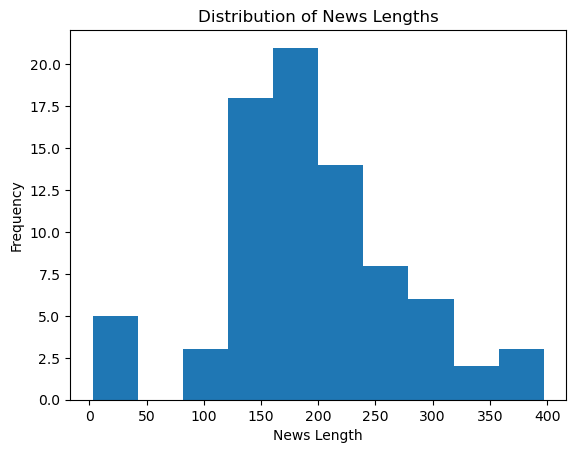

In [5]:
df['words'].apply(len).plot.hist(bins=10, 
                                 title='Distribution of News Lengths',
                                 xlabel='News Length')

In [6]:
df[df['words'].apply(len) < 50]

,title,text,url,publisher,dt,words
14,epaselect BRITAIN SOCCER,epaselect epa12536919 Iris Santiago of Real Ma...,https://v.daum.net/v/0IoWqIe41W,연합뉴스,58분 전,"[12536919, 19, 2025]"
34,epaselect BRITAIN SOCCER,epaselect epa12536919 Iris Santiago of Real Ma...,https://v.daum.net/v/0IoWqIe41W,연합뉴스,58분 전,"[12536919, 19, 2025]"
43,epaselect GERMANY SOCCER,epaselect epa12536881 Caitlin Dijkstra (L) of ...,https://v.daum.net/v/pSamM5Eo1V,연합뉴스,2025.11.20 18:08,"[12536881, 19, 2025]"
51,Function over form: Hong Myung-bo still has fo...,Opinions are split within the football communi...,https://v.daum.net/v/1iozGSnQWt,코리아중앙데일리,2025.11.20 17:30,"[12, 63, 50, 2013, 2014, 26.3, 10, 2026, 22, 1..."
74,epaselect FRANCE SOCCER,epaselect epa12536649 Fans of Benfica light re...,https://v.daum.net/v/pcnHlmx25F,연합뉴스,2025.11.20 16:06,"[12536649, 19, 2025]"


#### 3. Draw Word Cloud

1. Without any preprocessing

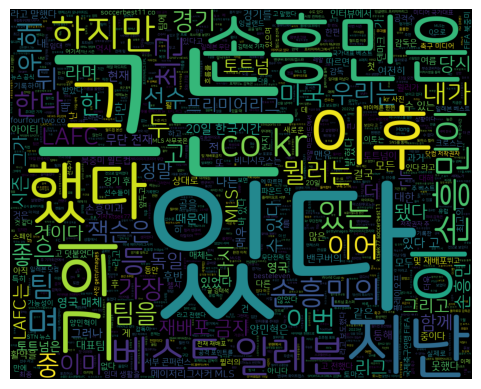

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


corpus = df['text']

text = ' '.join(corpus) # all text documents in one string
wc = WordCloud(font_path='NanumSquareRoundR.ttf', width=1000, height=800, max_words=1000).generate(text)
plt.imshow(wc)
plt.axis("off")
plt.show()

2. After applying NLP

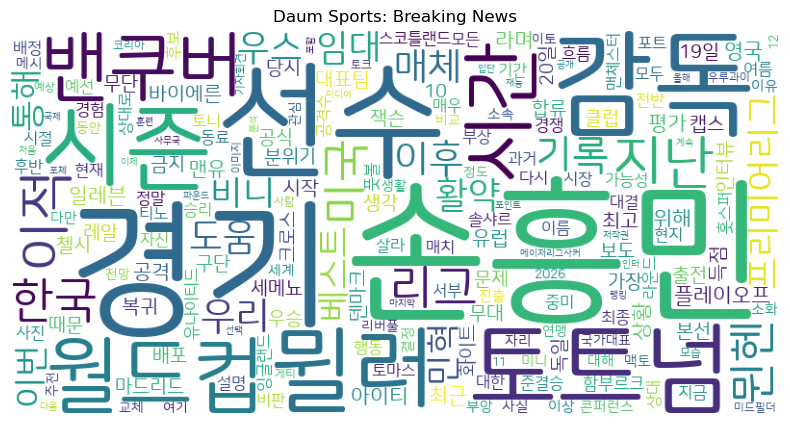

In [8]:
import itertools
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud

def flatten_list(list_of_lists):
    return list(itertools.chain.from_iterable(list_of_lists))

def draw_wordcloud(words, title=None):
    word_freq = Counter(words)
    wordcloud = WordCloud(font_path='./NanumSquareRoundR.ttf', 
                          width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


words_all = flatten_list(df['words'])
draw_wordcloud(words_all, title='Daum Sports: Breaking News')